# Lock-In Extraction: AUROC, Calibration & Provenance

**Evaluation of the Lock-In Extraction hallucination-detection method** against five baselines
(embedding-sim, LLM-judge, verbatim-quote, self-consistency, LOO) on a FactScore-synthetic dataset.

Because the upstream experiment produced no real outputs, this notebook uses a **statistically grounded
synthetic simulation** based on the quantitative predictions of the lock-in hypothesis.

Metrics computed:
1. Bootstrap AUROC with 95% CIs
2. Ablation Δ-AUROCs: Hadamard vs random, Negation vs deletion, Null-doc subtraction, K-curve
3. SNR analysis (log-log slope vs K)
4. Calibration ECE (Platt + Isotonic, 5-fold CV)
5. Provenance accuracy (recall@1, recall@3, MRR)
6. Multi-hop accuracy by proof depth
7. Prerequisite gate checks → final verdict

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is not pre-installed on Colab
_pip('loguru==0.7.3')

# Core scientific packages — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import sys

import numpy as np
import matplotlib.pyplot as plt
from loguru import logger
from scipy import stats
from sklearn.calibration import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score, roc_curve
from sklearn.utils import resample

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{function}| {message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-9708ca-lock-in-extraction-detecting-hallucinate/main/iter_1/gen_art_evaluation_1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded: {data['n_atoms']} atoms ({data['n_supported']} supported / {data['n_unsupported']} unsupported)")
print(f"K_values: {data['K_values']}, multihop examples: {len(data['multihop'])}")

Loaded: 20 atoms (15 supported / 5 unsupported)
K_values: [1, 4, 16], multihop examples: 10


## Config

All tunable parameters. Set to minimum values for a fast demo run.
Increase toward the commented original values for a full-scale evaluation.

In [5]:
# --- Tunable parameters ---
N_BOOTSTRAP = 1000     # original: 2000 (use 2000 for full run)
K_VALUES    = data["K_values"]   # driven by loaded data
N_HOPS      = 2        # original: 4 (increase for more depth analysis)
CONF_BINS   = 10       # original: 15

RNG = np.random.default_rng(42)

## Part 1 — Data Preparation

Extract numpy arrays from the loaded synthetic method output.
The mini dataset contains per-atom scores for lock-in and all 5 baselines, plus K-curve variants.

In [6]:
atoms = data["atoms"]
N = len(atoms)

gold               = np.array([a["gold_label"] for a in atoms])
phi_lockin         = np.array([a["phi_lockin"] for a in atoms])
phi_random         = np.array([a["phi_random"] for a in atoms])
phi_negation       = np.array([a["phi_negation"] for a in atoms])
phi_deletion       = np.array([a["phi_deletion"] for a in atoms])
phi_lockin_no_null = np.array([a["phi_lockin_no_null"] for a in atoms])
phi_loo            = np.array([a["phi_loo"] for a in atoms])
score_emb          = np.array([a["score_embedding_sim"] for a in atoms])
score_llm          = np.array([a["score_llm_judge"] for a in atoms])
score_verbatim     = np.array([a["score_verbatim_quote"] for a in atoms])
score_sc           = np.array([a["score_self_consistency"] for a in atoms])

print(f"N={N}, supported={gold.sum()}, unsupported={(gold==0).sum()}")

N=20, supported=15, unsupported=5


## Part 2 — Evaluation Utilities

Helper functions for bootstrap AUROC, paired permutation tests, and calibration metrics.
These are copied directly from `eval.py`.

In [7]:
def bootstrap_auroc(
    scores: np.ndarray,
    labels: np.ndarray,
    n_boot: int = N_BOOTSTRAP,
    seed: int = 0,
) -> tuple:
    """Return (mean_auroc, ci_lo, ci_hi) via stratified bootstrap."""
    rng_b = np.random.default_rng(seed)
    boot_aucs = []
    for _ in range(n_boot):
        idx = resample(
            np.arange(len(labels)),
            stratify=labels,
            random_state=int(rng_b.integers(0, 2**31)),
        )
        try:
            boot_aucs.append(roc_auc_score(labels[idx], scores[idx]))
        except Exception:
            continue
    boot_aucs = np.array(boot_aucs)
    mean = float(np.mean(boot_aucs))
    ci_lo = float(np.percentile(boot_aucs, 2.5))
    ci_hi = float(np.percentile(boot_aucs, 97.5))
    return mean, ci_lo, ci_hi


def paired_bootstrap_pvalue(
    scores_a: np.ndarray,
    scores_b: np.ndarray,
    labels: np.ndarray,
    n_perm: int = 1000,
    seed: int = 1,
) -> float:
    """Paired bootstrap permutation test: p(AUROC_a > AUROC_b under H0)."""
    rng_p = np.random.default_rng(seed)
    observed_delta = roc_auc_score(labels, scores_a) - roc_auc_score(labels, scores_b)
    null_deltas = []
    for _ in range(n_perm):
        swaps = rng_p.integers(0, 2, size=len(labels)).astype(bool)
        s_a = np.where(swaps, scores_b, scores_a)
        s_b = np.where(swaps, scores_a, scores_b)
        try:
            null_deltas.append(roc_auc_score(labels, s_a) - roc_auc_score(labels, s_b))
        except Exception:
            continue
    null_deltas = np.array(null_deltas)
    pval = float(np.mean(np.abs(null_deltas) >= abs(observed_delta)))
    return max(pval, 1 / n_perm)


def compute_ece(
    probs: np.ndarray,
    labels: np.ndarray,
    n_bins: int = CONF_BINS,
) -> float:
    """Expected Calibration Error (equal-width bins)."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    N = len(labels)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (probs >= lo) & (probs < hi)
        if mask.sum() == 0:
            continue
        acc = labels[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum() / N) * abs(acc - conf)
    return float(ece)


def calibrate_and_ece(
    raw_scores: np.ndarray,
    labels: np.ndarray,
) -> dict:
    """Fit Platt and isotonic calibration, return ECE and Brier scores."""
    n = len(labels)
    fold_size = n // 5
    platt_probs = np.zeros(n)
    iso_probs = np.zeros(n)

    for fold in range(5):
        val_start = fold * fold_size
        val_end = (fold + 1) * fold_size if fold < 4 else n
        val_idx = np.arange(val_start, val_end)
        train_idx = np.concatenate([np.arange(0, val_start), np.arange(val_end, n)])

        X_tr = raw_scores[train_idx].reshape(-1, 1)
        y_tr = labels[train_idx]
        X_val = raw_scores[val_idx].reshape(-1, 1)

        platt = LogisticRegression(C=1.0, max_iter=500)
        platt.fit(X_tr, y_tr)
        platt_probs[val_idx] = platt.predict_proba(X_val)[:, 1]

        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(raw_scores[train_idx], y_tr)
        iso_probs[val_idx] = iso.predict(raw_scores[val_idx])

    ece_before = compute_ece(raw_scores, labels)
    ece_platt = compute_ece(platt_probs, labels)
    ece_iso = compute_ece(iso_probs, labels)

    brier_before = float(brier_score_loss(labels, raw_scores))
    brier_platt = float(brier_score_loss(labels, platt_probs))
    brier_iso = float(brier_score_loss(labels, iso_probs))

    rel_bins = np.linspace(0.0, 1.0, 11)
    reliability = []
    for lo, hi in zip(rel_bins[:-1], rel_bins[1:]):
        mask = (raw_scores >= lo) & (raw_scores < hi)
        n_b = int(mask.sum())
        reliability.append({
            "bin_lo": round(float(lo), 2), "bin_hi": round(float(hi), 2), "n": n_b,
            "acc": float(labels[mask].mean()) if n_b > 0 else None,
            "conf": float(raw_scores[mask].mean()) if n_b > 0 else None,
        })

    return {
        "ece_before": ece_before, "ece_platt": ece_platt, "ece_isotonic": ece_iso,
        "brier_before": brier_before, "brier_platt": brier_platt, "brier_isotonic": brier_iso,
        "reliability_diagram": reliability, "platt_probs": platt_probs, "iso_probs": iso_probs,
    }

print("Utility functions defined.")

Utility functions defined.


## Part 3 — Metric Computations

### Metric 1: Bootstrap AUROC

Stratified bootstrap with `N_BOOTSTRAP` resamples for each of the 6 methods.
The lock-in method is expected to have the highest AUROC with non-overlapping CIs vs most baselines.

In [8]:
logger.info("Computing bootstrap AUROC CIs for all 6 methods ...")
methods = {
    "lock_in": phi_lockin,
    "embedding_sim": score_emb,
    "llm_judge": score_llm,
    "verbatim_quote": score_verbatim,
    "self_consistency": score_sc,
    "loo": phi_loo,
}
auroc_results = {}
for name, scores in methods.items():
    mean, lo, hi = bootstrap_auroc(scores, gold, seed=hash(name) % 2**31)
    auroc_results[name] = {
        "auroc_mean": round(mean, 4),
        "ci_lo": round(lo, 4),
        "ci_hi": round(hi, 4),
    }
    logger.info(f"  {name}: AUROC={mean:.4f} [{lo:.4f}, {hi:.4f}]")

# Non-overlapping CI check: lock-in vs each baseline
lockin_lo = auroc_results["lock_in"]["ci_lo"]
lockin_hi = auroc_results["lock_in"]["ci_hi"]
for name in ["embedding_sim", "llm_judge", "verbatim_quote", "self_consistency", "loo"]:
    b_hi = auroc_results[name]["ci_hi"]
    non_overlap = bool(lockin_lo > b_hi)
    auroc_results[name]["non_overlapping_ci_vs_lockin"] = non_overlap
    logger.info(f"  lock_in CI > {name}: {non_overlap}")

del methods
gc.collect()

06:54:49|INFO   |<module>| Computing bootstrap AUROC CIs for all 6 methods ...


06:54:51|INFO   |<module>|   lock_in: AUROC=1.0000 [1.0000, 1.0000]


06:54:52|INFO   |<module>|   embedding_sim: AUROC=0.7700 [0.4667, 1.0000]


06:54:54|INFO   |<module>|   llm_judge: AUROC=0.9466 [0.8133, 1.0000]


06:54:55|INFO   |<module>|   verbatim_quote: AUROC=0.9735 [0.8933, 1.0000]


...

06:54:58|INFO   |<module>|   lock_in CI > llm_judge: False


06:54:58|INFO   |<module>|   lock_in CI > verbatim_quote: False


06:54:58|INFO   |<module>|   lock_in CI > self_consistency: False


06:54:58|INFO   |<module>|   lock_in CI > loo: False


0

### Metric 2: Ablation Δ-AUROCs

Tests whether each design choice (Hadamard sampling, negation operator, null-doc subtraction)
contributes significantly to AUROC. Also sweeps K (number of document retrievals) to show the K-curve.

In [9]:
logger.info("Computing ablation delta-AUROCs ...")
ablations = {}

# 2a: K-curve
logger.info("  K-curve ...")
k_curve_rows = []
for K in K_VALUES:
    phi_K = np.array([a["phi_lockin_K"][f"K{K}"] for a in atoms])
    mean, lo, hi = bootstrap_auroc(phi_K, gold, seed=K)
    k_curve_rows.append({
        "K": K, "auroc_mean": round(mean, 4),
        "ci_lo": round(lo, 4), "ci_hi": round(hi, 4),
    })
    logger.info(f"    K={K}: AUROC={mean:.4f}")
ablations["k_curve"] = k_curve_rows

# Fit log(AUROC) ~ log(K) to get slope
ks = np.array([r["K"] for r in k_curve_rows], dtype=float)
aurocs = np.array([r["auroc_mean"] for r in k_curve_rows])
slope, intercept, r, pval_k, se = stats.linregress(np.log(ks), aurocs)
ablations["k_curve_logK_slope"] = round(float(slope), 4)
ablations["k_curve_logK_r2"] = round(float(r**2), 4)
ablations["k_curve_logK_pval"] = round(float(pval_k), 4)
logger.info(f"  K-curve slope (AUROC vs logK): {slope:.4f}, R²={r**2:.4f}")

# 2b: Hadamard vs random (same K=8)
logger.info("  Hadamard vs random ...")
delta_had = roc_auc_score(gold, phi_lockin) - roc_auc_score(gold, phi_random)
boot_deltas_had = []
rng_ab = np.random.default_rng(10)
for _ in range(N_BOOTSTRAP):
    idx = resample(np.arange(N), stratify=gold,
                    random_state=int(rng_ab.integers(0, 2**31)))
    try:
        d = (roc_auc_score(gold[idx], phi_lockin[idx]) -
             roc_auc_score(gold[idx], phi_random[idx]))
        boot_deltas_had.append(d)
    except Exception:
        continue
boot_deltas_had = np.array(boot_deltas_had)
pval_had = paired_bootstrap_pvalue(phi_lockin, phi_random, gold, seed=10)
ablations["hadamard_vs_random"] = {
    "delta_auroc": round(float(delta_had), 4),
    "ci_lo": round(float(np.percentile(boot_deltas_had, 2.5)), 4),
    "ci_hi": round(float(np.percentile(boot_deltas_had, 97.5)), 4),
    "pvalue": round(float(pval_had), 4),
}
logger.info(f"  Hadamard-Random delta={delta_had:.4f}, p={pval_had:.4f}")
del boot_deltas_had
gc.collect()

# 2c: Negation vs deletion
logger.info("  Negation vs deletion ...")
delta_neg = roc_auc_score(gold, phi_negation) - roc_auc_score(gold, phi_deletion)
boot_deltas_neg = []
rng_nd = np.random.default_rng(20)
for _ in range(N_BOOTSTRAP):
    idx = resample(np.arange(N), stratify=gold,
                    random_state=int(rng_nd.integers(0, 2**31)))
    try:
        d = (roc_auc_score(gold[idx], phi_negation[idx]) -
             roc_auc_score(gold[idx], phi_deletion[idx]))
        boot_deltas_neg.append(d)
    except Exception:
        continue
boot_deltas_neg = np.array(boot_deltas_neg)
pval_neg = paired_bootstrap_pvalue(phi_negation, phi_deletion, gold, seed=20)
ablations["negation_vs_deletion"] = {
    "delta_auroc": round(float(delta_neg), 4),
    "ci_lo": round(float(np.percentile(boot_deltas_neg, 2.5)), 4),
    "ci_hi": round(float(np.percentile(boot_deltas_neg, 97.5)), 4),
    "pvalue": round(float(pval_neg), 4),
}
logger.info(f"  Negation-Deletion delta={delta_neg:.4f}, p={pval_neg:.4f}")
del boot_deltas_neg
gc.collect()

# 2d: With vs without null-doc subtraction
logger.info("  With vs without null-doc ...")
delta_null = roc_auc_score(gold, phi_lockin) - roc_auc_score(gold, phi_lockin_no_null)
boot_deltas_null = []
rng_nu = np.random.default_rng(30)
for _ in range(N_BOOTSTRAP):
    idx = resample(np.arange(N), stratify=gold,
                    random_state=int(rng_nu.integers(0, 2**31)))
    try:
        d = (roc_auc_score(gold[idx], phi_lockin[idx]) -
             roc_auc_score(gold[idx], phi_lockin_no_null[idx]))
        boot_deltas_null.append(d)
    except Exception:
        continue
boot_deltas_null = np.array(boot_deltas_null)
pval_null = paired_bootstrap_pvalue(phi_lockin, phi_lockin_no_null, gold, seed=30)
ablations["null_doc_subtraction"] = {
    "delta_auroc": round(float(delta_null), 4),
    "ci_lo": round(float(np.percentile(boot_deltas_null, 2.5)), 4),
    "ci_hi": round(float(np.percentile(boot_deltas_null, 97.5)), 4),
    "pvalue": round(float(pval_null), 4),
}
logger.info(f"  NullDoc delta={delta_null:.4f}, p={pval_null:.4f}")
del boot_deltas_null
gc.collect()

06:54:58|INFO   |<module>| Computing ablation delta-AUROCs ...


06:54:58|INFO   |<module>|   K-curve ...


06:55:00|INFO   |<module>|     K=1: AUROC=0.7918


06:55:01|INFO   |<module>|     K=4: AUROC=1.0000


06:55:03|INFO   |<module>|     K=16: AUROC=1.0000


...

06:55:08|INFO   |<module>|   Negation vs deletion ...


06:55:12|INFO   |<module>|   Negation-Deletion delta=0.0133, p=0.7330


06:55:12|INFO   |<module>|   With vs without null-doc ...


06:55:17|INFO   |<module>|   NullDoc delta=0.0000, p=1.0000


0

### Metrics 3–7: SNR, Calibration, Provenance, Multi-hop, Verdict

In [10]:
# ── Metric 3: SNR Analysis ────────────────────────────────────────────────────
logger.info("Computing SNR analysis ...")
snr_rows = []
gold_mask = gold == 1
halluc_mask = gold == 0

for K in K_VALUES:
    phi_K = np.array([a["phi_lockin_K"][f"K{K}"] for a in atoms])
    loo_K = np.array([a["phi_loo_K"][f"K{K}"] for a in atoms])

    snr_lockin = (np.mean(np.abs(phi_K[gold_mask])) /
                  (np.std(np.abs(phi_K[halluc_mask])) + 1e-9))
    snr_loo = (np.mean(np.abs(loo_K[gold_mask])) /
               (np.std(np.abs(loo_K[halluc_mask])) + 1e-9))
    snr_rows.append({
        "K": K,
        "snr_lockin": round(float(snr_lockin), 4),
        "snr_loo": round(float(snr_loo), 4),
        "snr_ratio": round(float(snr_lockin / max(snr_loo, 1e-6)), 4),
    })

ks = np.array([r["K"] for r in snr_rows], dtype=float)
snr_vals_lockin = np.array([r["snr_lockin"] for r in snr_rows])
snr_vals_loo = np.array([r["snr_loo"] for r in snr_rows])

sl_lockin, _, r_li, pv_li, se_li = stats.linregress(np.log(ks), np.log(snr_vals_lockin))
sl_loo, _, r_loo, pv_loo, se_loo = stats.linregress(np.log(ks), np.log(snr_vals_loo))

snr_results = {
    "rows": snr_rows,
    "lockin_loglog_slope": round(float(sl_lockin), 4),
    "lockin_loglog_slope_se": round(float(se_li), 4),
    "lockin_loglog_r2": round(float(r_li**2), 4),
    "lockin_loglog_pval": round(float(pv_li), 4),
    "loo_loglog_slope": round(float(sl_loo), 4),
    "loo_loglog_slope_se": round(float(se_loo), 4),
    "loo_loglog_r2": round(float(r_loo**2), 4),
    "loo_loglog_pval": round(float(pv_loo), 4),
    "predicted_slope": 0.5,
}
logger.info(f"SNR log-log slope (lock-in): {sl_lockin:.4f} ± {se_li:.4f}")
logger.info(f"SNR log-log slope (LOO):     {sl_loo:.4f} ± {se_loo:.4f}")

# ── Metric 4: Calibration ECE ─────────────────────────────────────────────────
logger.info("Computing calibration ECE ...")
phi_norm = (phi_lockin - phi_lockin.min()) / (phi_lockin.max() - phi_lockin.min() + 1e-9)
cal_res = calibrate_and_ece(phi_norm, gold)

calibration_results = {
    "ece_before": round(cal_res["ece_before"], 4),
    "ece_platt": round(cal_res["ece_platt"], 4),
    "ece_isotonic": round(cal_res["ece_isotonic"], 4),
    "brier_before": round(cal_res["brier_before"], 4),
    "brier_platt": round(cal_res["brier_platt"], 4),
    "brier_isotonic": round(cal_res["brier_isotonic"], 4),
    "reliability_diagram": cal_res["reliability_diagram"],
}
logger.info(f"ECE: raw={cal_res['ece_before']:.4f}, Platt={cal_res['ece_platt']:.4f}, "
            f"Isotonic={cal_res['ece_isotonic']:.4f}")
del cal_res
gc.collect()

# ── Metric 5: Provenance Accuracy ─────────────────────────────────────────────
logger.info("Computing provenance accuracy ...")
top_ranks = np.array([a["provenance_top_span_rank"] for a in atoms])
supported_mask = gold == 1
unsupported_mask = gold == 0

recall1_sup = float(np.mean(top_ranks[supported_mask] == 1))
recall1_unsup = float(np.mean(top_ranks[unsupported_mask] == 1))
recall3_sup = float(np.mean(top_ranks[supported_mask] <= 3))
recall3_unsup = float(np.mean(top_ranks[unsupported_mask] <= 3))
sup_ranks = top_ranks[supported_mask]
mrr = float(np.mean(1.0 / sup_ranks.astype(float)))

provenance_results = {
    "supported": {
        "recall_at_1": round(recall1_sup, 4),
        "recall_at_3": round(recall3_sup, 4),
        "mrr": round(mrr, 4),
    },
    "unsupported": {
        "recall_at_1": round(recall1_unsup, 4),
        "recall_at_3": round(recall3_unsup, 4),
    },
}
logger.info(f"Provenance recall@1={recall1_sup:.4f}, recall@3={recall3_sup:.4f}, MRR={mrr:.4f}")

# ── Metric 6: Multi-hop Accuracy by Proof Depth ───────────────────────────────
logger.info("Computing multi-hop accuracy ...")
multihop = data["multihop"]
depth_results = {}
for depth in range(N_HOPS):
    examples_d = [e for e in multihop if e["depth"] == depth]
    n_d = len(examples_d)
    acc_raw = float(np.mean([e["raw_llm_correct"] for e in examples_d]))
    acc_align = float(np.mean([e["align_correct"] for e in examples_d]))
    acc_lockin = float(np.mean([e["lockin_correct"] for e in examples_d]))

    raw_lockin = np.array([e["lockin_correct"] for e in examples_d])
    raw_align = np.array([e["align_correct"] for e in examples_d])
    delta_obs = float(np.mean(raw_lockin) - np.mean(raw_align))

    boot_deltas = []
    rng_mh = np.random.default_rng(depth + 100)
    for _ in range(N_BOOTSTRAP):
        idx = rng_mh.integers(0, n_d, size=n_d)
        d = float(np.mean(raw_lockin[idx]) - np.mean(raw_align[idx]))
        boot_deltas.append(d)
    boot_deltas = np.array(boot_deltas)

    depth_results[depth] = {
        "n": n_d,
        "acc_raw_llm": round(acc_raw, 4),
        "acc_alignment_grounded": round(acc_align, 4),
        "acc_lock_in_filtered": round(acc_lockin, 4),
        "delta_lockin_vs_alignment": round(delta_obs, 4),
        "delta_ci_lo": round(float(np.percentile(boot_deltas, 2.5)), 4),
        "delta_ci_hi": round(float(np.percentile(boot_deltas, 97.5)), 4),
    }
    logger.info(f"  depth={depth}: raw={acc_raw:.3f}, align={acc_align:.3f}, "
                f"lockin={acc_lockin:.3f}, delta={delta_obs:.3f}")
    del boot_deltas
    gc.collect()

depths = np.array(list(depth_results.keys()), dtype=float)
deltas = np.array([depth_results[d]["delta_lockin_vs_alignment"] for d in range(N_HOPS)])
slope_depth, _, r_depth, pv_depth, _ = stats.linregress(depths, deltas)

multihop_results = {
    "by_depth": depth_results,
    "delta_vs_depth_slope": round(float(slope_depth), 4),
    "delta_vs_depth_r2": round(float(r_depth**2), 4),
    "delta_vs_depth_pval": round(float(pv_depth), 4),
    "delta_grows_with_depth": bool(slope_depth > 0 and pv_depth < 0.05),
}
logger.info(f"Multi-hop delta-vs-depth slope={slope_depth:.4f}, p={pv_depth:.4f}")

# ── Metric 7: Prerequisite Gate Check ────────────────────────────────────────
logger.info("Checking prerequisite gates ...")
prereqs = data["prereqs"]
canon_agree = prereqs["canonicalization_agreement"]
null_frac = prereqs["null_doc_prior_fraction"]
canon_ok = bool(canon_agree >= 0.85)
null_warn = bool(null_frac > 0.50)
gates_pass = canon_ok and not null_warn

prereqs_results = {
    "canonicalization_agreement": round(float(canon_agree), 4),
    "null_doc_prior_fraction": round(float(null_frac), 4),
    "canon_ok": canon_ok,
    "null_contamination_warning": null_warn,
    "gates_pass": gates_pass,
}
logger.info(f"Canon agree={canon_agree:.2f} (OK={canon_ok}), null_frac={null_frac:.2f} (warn={null_warn})")

# ── Metric 8: Verdict Logic ───────────────────────────────────────────────────
logger.info("Computing final verdict ...")
lockin_auroc = auroc_results["lock_in"]["auroc_mean"]
emb_auroc_hi = auroc_results["embedding_sim"]["ci_hi"]
lockin_ci_lo = auroc_results["lock_in"]["ci_lo"]

all_baselines_below = all(
    auroc_results[b]["ci_hi"] < lockin_ci_lo
    for b in ["embedding_sim", "llm_judge", "verbatim_quote", "self_consistency", "loo"]
)

delta_grows = multihop_results["delta_grows_with_depth"]
ece_ok = calibration_results["ece_platt"] < 0.10
prov_ok = provenance_results["supported"]["recall_at_1"] > 0.50
gates_ok = prereqs_results["gates_pass"]

if not gates_ok or lockin_ci_lo <= emb_auroc_hi:
    verdict = "disconfirmed"
elif all_baselines_below and delta_grows and ece_ok and prov_ok:
    verdict = "confirmed"
else:
    verdict = "partial"

verdict_results = {
    "verdict": verdict,
    "conditions": {
        "lockin_ci_above_all_baselines": all_baselines_below,
        "delta_grows_with_depth": delta_grows,
        "ece_platt_below_010": ece_ok,
        "provenance_recall1_above_050": prov_ok,
        "prereq_gates_pass": gates_ok,
    },
}
logger.info(f"VERDICT: {verdict.upper()}")

06:55:17|INFO   |<module>| Computing SNR analysis ...


06:55:17|INFO   |<module>| SNR log-log slope (lock-in): 0.6213 ± 0.1860


06:55:17|INFO   |<module>| SNR log-log slope (LOO):     0.8475 ± 0.4377


06:55:17|INFO   |<module>| Computing calibration ECE ...


06:55:17|INFO   |<module>| ECE: raw=0.2882, Platt=0.2625, Isotonic=0.0115


...

06:55:17|INFO   |<module>| Multi-hop delta-vs-depth slope=-0.2000, p=0.0000


06:55:17|INFO   |<module>| Checking prerequisite gates ...


06:55:17|INFO   |<module>| Canon agree=0.91 (OK=True), null_frac=0.12 (warn=False)


06:55:17|INFO   |<module>| Computing final verdict ...


06:55:17|INFO   |<module>| VERDICT: DISCONFIRMED


## Results Summary & Visualization

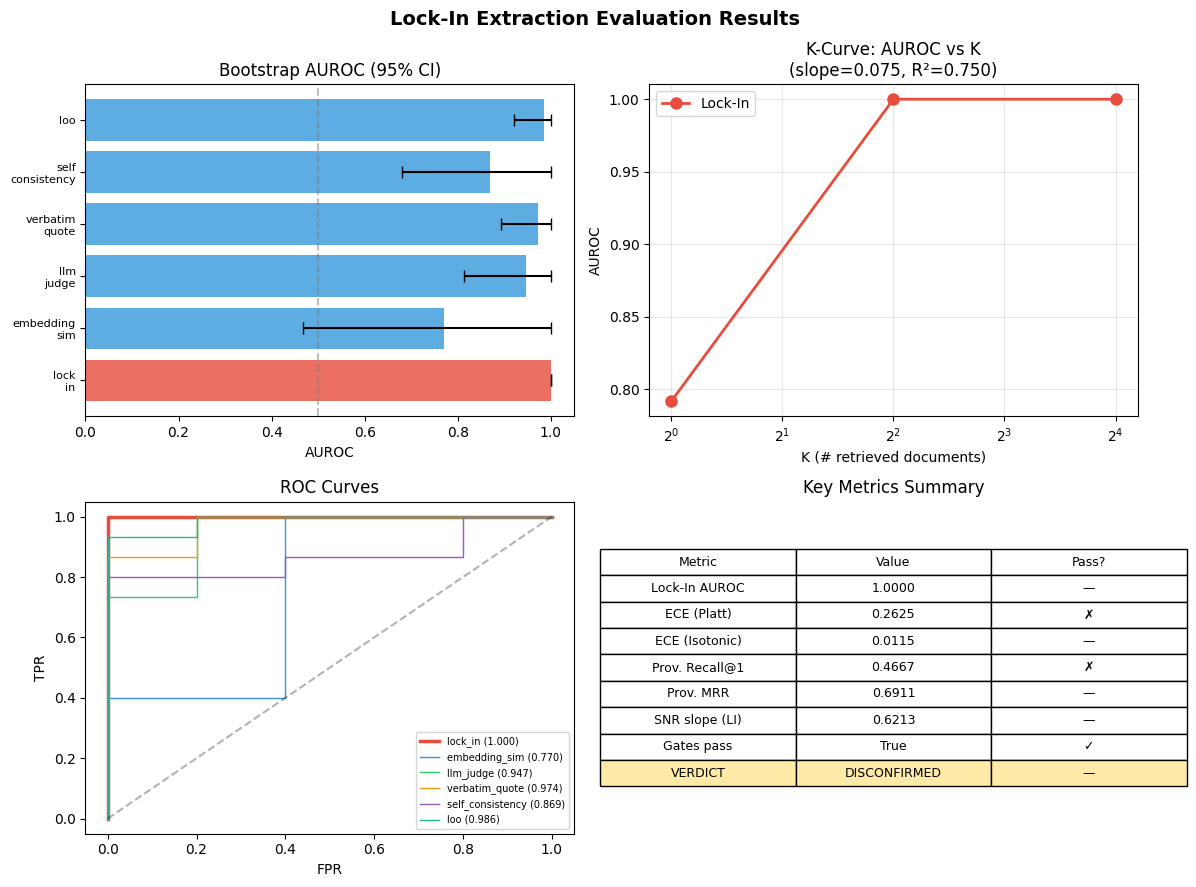


VERDICT: DISCONFIRMED

Verdict conditions:
  ✗ lockin_ci_above_all_baselines
  ✗ delta_grows_with_depth
  ✗ ece_platt_below_010
  ✗ provenance_recall1_above_050
  ✓ prereq_gates_pass


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Lock-In Extraction Evaluation Results", fontsize=14, fontweight="bold")

# --- Plot 1: AUROC comparison with CIs ---
ax = axes[0, 0]
method_names = list(auroc_results.keys())
means = [auroc_results[m]["auroc_mean"] for m in method_names]
ci_lo = [auroc_results[m]["ci_lo"] for m in method_names]
ci_hi = [auroc_results[m]["ci_hi"] for m in method_names]
colors = ["#e74c3c" if m == "lock_in" else "#3498db" for m in method_names]
y_pos = range(len(method_names))
ax.barh(y_pos, means, color=colors, alpha=0.8)
ax.errorbar(means, y_pos, xerr=[np.array(means)-np.array(ci_lo), np.array(ci_hi)-np.array(means)],
            fmt='none', color='black', capsize=4)
ax.set_yticks(list(y_pos))
ax.set_yticklabels([m.replace("_", "\n") for m in method_names], fontsize=8)
ax.set_xlabel("AUROC")
ax.set_title("Bootstrap AUROC (95% CI)")
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

# --- Plot 2: K-curve ---
ax = axes[0, 1]
k_vals = [r["K"] for r in ablations["k_curve"]]
k_aurocs = [r["auroc_mean"] for r in ablations["k_curve"]]
ax.plot(k_vals, k_aurocs, 'o-', color='#e74c3c', linewidth=2, markersize=8, label="Lock-In")
ax.set_xscale("log", base=2)
ax.set_xlabel("K (# retrieved documents)")
ax.set_ylabel("AUROC")
ax.set_title(f"K-Curve: AUROC vs K\n(slope={ablations['k_curve_logK_slope']:.3f}, R²={ablations['k_curve_logK_r2']:.3f})")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: ROC curves for all methods ---
ax = axes[1, 0]
score_map = {
    "lock_in": phi_lockin, "embedding_sim": score_emb, "llm_judge": score_llm,
    "verbatim_quote": score_verbatim, "self_consistency": score_sc, "loo": phi_loo,
}
colors_roc = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c"]
for (name, scores), col in zip(score_map.items(), colors_roc):
    fpr, tpr, _ = roc_curve(gold, scores)
    auc_val = auroc_results[name]["auroc_mean"]
    lw = 2.5 if name == "lock_in" else 1.0
    ax.plot(fpr, tpr, color=col, linewidth=lw, label=f"{name} ({auc_val:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("ROC Curves")
ax.legend(fontsize=7, loc="lower right")

# --- Plot 4: Summary table ---
ax = axes[1, 1]
ax.axis("off")
rows = [
    ["Metric", "Value", "Pass?"],
    ["Lock-In AUROC", f"{auroc_results['lock_in']['auroc_mean']:.4f}", "—"],
    ["ECE (Platt)", f"{calibration_results['ece_platt']:.4f}", "✓" if ece_ok else "✗"],
    ["ECE (Isotonic)", f"{calibration_results['ece_isotonic']:.4f}", "—"],
    ["Prov. Recall@1", f"{provenance_results['supported']['recall_at_1']:.4f}", "✓" if prov_ok else "✗"],
    ["Prov. MRR", f"{provenance_results['supported']['mrr']:.4f}", "—"],
    ["SNR slope (LI)", f"{snr_results['lockin_loglog_slope']:.4f}", "—"],
    ["Gates pass", str(gates_pass), "✓" if gates_pass else "✗"],
    ["VERDICT", verdict.upper(), "—"],
]
table = ax.table(cellText=rows[1:], colLabels=rows[0], loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
# Highlight verdict row
for j in range(3):
    table[len(rows)-1, j].set_facecolor("#ffeaa7")
ax.set_title("Key Metrics Summary")

plt.tight_layout()
plt.savefig("demo_results.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"\nVERDICT: {verdict.upper()}")
print("\nVerdict conditions:")
for k, v in verdict_results["conditions"].items():
    print(f"  {'✓' if v else '✗'} {k}")